In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [267]:
def load_data():
  data = pd.read_csv("perceptron_data.csv")
  X = data[["x1", "x2"]].values
  y = data["y"].values
  return X, y

In [268]:
def add_bias(X):
    return np.column_stack((np.ones(X.shape[0]), X))

In [269]:
def initialize_parameters(n_features):
    return np.random.randn(n_features)

In [270]:
def predict(X, weights):
    scores = X @ weights

    return np.where(
        scores > 0,
        1,
        -1
    )

In [271]:
def compute_loss(X, y, weights):
    scores = X @ weights

    losses = np.maximum(
        0,
        -y * scores
    )

    return np.mean(losses)

In [272]:
def update_weights(weights, x, y, learning_rate):
    if y * (weights @ x) <= 0:
        weights = weights + learning_rate * y * x

    return weights

In [273]:
def train_perceptron(X, y, learning_rate=1.0, epochs=100):

    initial_weights = initialize_parameters(X.shape[1])
    weights = initial_weights.copy()

    error_history = []
    loss_history = []
    weight_history = [weights.copy()]

    for epoch in range(epochs):

        errors = 0

        for i in range(len(X)):

            if y[i] * (weights @ X[i]) <= 0:

                weights = update_weights(
                    weights,
                    X[i],
                    y[i],
                    learning_rate
                )

                errors += 1

                weight_history.append(weights.copy())

        error_history.append(errors)

        loss = compute_loss(X, y, weights)
        loss_history.append(loss)

    return (
        initial_weights,
        weights,
        error_history,
        loss_history,
        weight_history
    )

In [274]:
def plot_data(X, y):
    positive = y == 1
    negative = y == -1

    plt.scatter(
        X[positive, 1],
        X[positive, 2],
        label="+1"
    )

    plt.scatter(
        X[negative, 1],
        X[negative, 2],
        label="-1"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)

In [275]:
def plot_decision_boundary(X, weights, label="Decision Boundary"):
    x1_values = np.linspace(
        X[:, 1].min() - 1,
        X[:, 1].max() + 1,
        100
    )

    if weights[2] == 0:
        x1_value = -weights[0] / weights[1]

        plt.axvline(
            x1_value,
            label=label
        )
    else:
        x2_values = -(
            weights[0] +
            weights[1] * x1_values
        ) / weights[2]

        plt.plot(
            x1_values,
            x2_values,
            label=label
        )

In [276]:
def animate_training(X, y, weight_history):

    fig, ax = plt.subplots(figsize=(8, 6))

    # -----------------------------
    # Plot training data
    # -----------------------------

    positive = y == 1
    negative = y == -1

    ax.scatter(
        X[positive, 1],
        X[positive, 2],
        label="+1"
    )

    ax.scatter(
        X[negative, 1],
        X[negative, 2],
        label="-1"
    )

    # -----------------------------
    # X-axis values for boundary
    # -----------------------------

    x1_values = np.linspace(
        X[:, 1].min() - 1,
        X[:, 1].max() + 1,
        100
    )

    # Empty line initially
    line, = ax.plot(
        [],
        [],
        linewidth=2,
        label="Decision Boundary"
    )

    ax.set_xlim(
        X[:, 1].min() - 1,
        X[:, 1].max() + 1
    )

    ax.set_ylim(
        X[:, 2].min() - 1,
        X[:, 2].max() + 1
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.grid(True)

    # -----------------------------
    # Animation update
    # -----------------------------

    def update(frame):

        weights = weight_history[frame]

        if weights[2] != 0:

            x2_values = (
                -(weights[0] + weights[1] * x1_values)
                / weights[2]
            )

            line.set_data(
                x1_values,
                x2_values
            )

        ax.set_title(
            f"Perceptron Learning - Step {frame}"
        )

        return line,

    # -----------------------------
    # Create animation
    # -----------------------------

    animation = FuncAnimation(
        fig,
        update,
        frames=len(weight_history),
        interval=500,
        repeat=False
    )

    plt.close(fig)

    return animation

In [277]:
X, y = load_data() #Data has been loaded

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 2)
y shape: (100,)


In [278]:
X = add_bias(X) #Bias has been added

In [279]:
#TASK-A: Decision Boundary Investigation
#weights = np.array([0.0, 1.0, -1.0])
#weights = np.array([2.0, 1.0, -1.0])
weights = np.array([0.0, 2.0, -1.0])

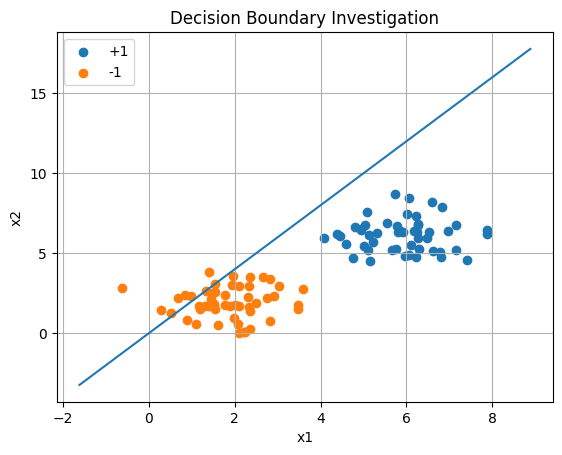

In [280]:
plot_data(X, y)
plot_decision_boundary(X, weights)

plt.title("Decision Boundary Investigation")
plt.show()

In [281]:
#Training
np.random.seed(42)

initial_weights, final_weights, error_history, loss_history, weight_history = \
    train_perceptron(
        X,
        y,
        learning_rate=1.0,
        epochs=100
    )

In [282]:
#TASK-B: Perceptron Predictions
predictions = predict(
    X,
    final_weights
)

print("Initial weights:")
print(initial_weights)

print("\nFinal weights:")
print(final_weights)

print("\nErrors per epoch:")
print(error_history)

print("\nLosses per epoch:")
print(loss_history)

print("\nFinal predictions:")
print(predictions)

print("\nActual labels:")
print(y)

print(
    "\nFinal errors:",
    np.sum(predictions != y)
)

Initial weights:
[ 0.49671415 -0.1382643   0.64768854]

Final weights:
[-11.50328585   1.41227615   2.19563302]

Errors per epoch:
[26, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Losses per epoch:
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.

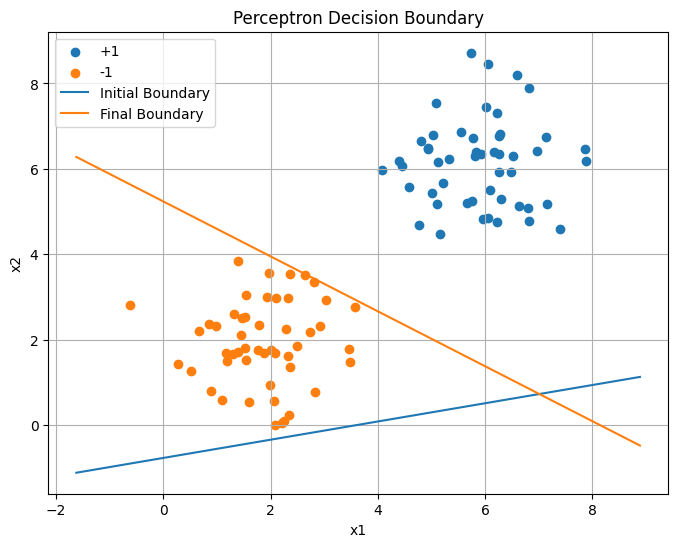

In [283]:
#TASK-C: Boundary Plots
plt.figure(figsize=(8, 6))

plot_data(X, y)

plot_decision_boundary(
    X,
    initial_weights,
    "Initial Boundary"
)

plot_decision_boundary(
    X,
    final_weights,
    "Final Boundary"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

In [284]:
animation = animate_training(
    X,
    y,
    weight_history
)

display(HTML(animation.to_jshtml()))

/usr/local/lib/python3.13/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


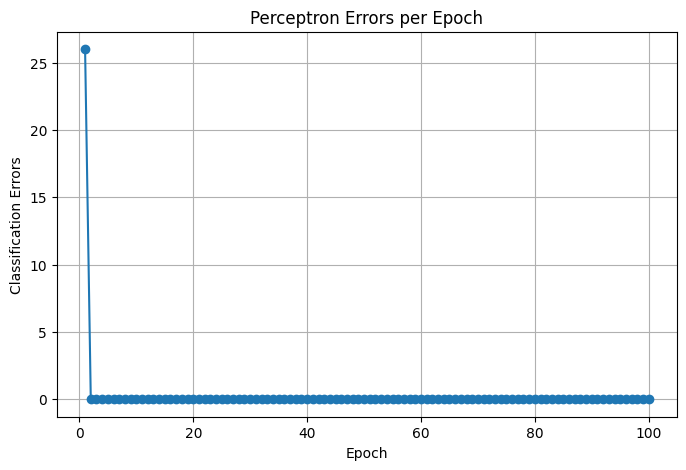

In [285]:
#Error Plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(error_history) + 1),
    error_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Errors")
plt.title("Perceptron Errors per Epoch")
plt.grid(True)
plt.show()

In [286]:
zero_error_epochs = np.where(
    np.array(error_history) == 0
)[0]

In [287]:
if len(zero_error_epochs) > 0:
    first_zero_epoch = zero_error_epochs[0] + 1
    print(
        "First epoch with zero errors:",
        first_zero_epoch
    )
else:
    print("The model did not reach zero errors.")

First epoch with zero errors: 2


In [288]:
if np.all(predictions == y):
    print("Yes, all training examples were correctly classified.")
else:
    print("No, some training examples were misclassified.")

Yes, all training examples were correctly classified.


In [289]:
#TASK-D: XOR Plots
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_xor = np.array([
    1,
    -1,
    -1,
    1
])

In [290]:
X_xor = np.column_stack((
    np.ones(X_xor.shape[0]),
    X_xor
))

In [291]:
np.random.seed(42)

weights = np.random.randn(3)

print("Initial weights:", weights)

Initial weights: [ 0.49671415 -0.1382643   0.64768854]


In [292]:
weight_history = [weights.copy()]
update_info = ["Initial"]

In [293]:
def animate_xor_training(X, y, weight_history, interval=500):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot XOR points
    positive = y == 1
    negative = y == -1

    ax.scatter(
        X[positive, 1],
        X[positive, 2],
        marker="o",
        s=100,
        label="+1"
    )

    ax.scatter(
        X[negative, 1],
        X[negative, 2],
        marker="x",
        s=100,
        label="-1"
    )

    # Set graph limits
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title("XOR - Perceptron Learning")
    ax.grid(True)
    ax.legend()

    # Initial line
    line, = ax.plot([], [], linewidth=2)

    x1_values = np.linspace(-0.5, 1.5, 100)

    def update(frame):
        weights = weight_history[frame]

        if weights[2] != 0:
            x2_values = (
                -(weights[0] + weights[1] * x1_values)
                / weights[2]
            )

            line.set_data(x1_values, x2_values)

        ax.set_title(
            f"XOR - Perceptron Learning\n"
            f"Step {frame + 1}/{len(weight_history)}"
        )

        return line,

    animation = FuncAnimation(
        fig,
        update,
        frames=len(weight_history),
        interval=interval,
        repeat=False
    )

    plt.close(fig)

    return animation

In [294]:
xor_initial, xor_final, xor_errors, xor_losses, xor_error_history = train_perceptron(
    X_xor,
    y_xor,
    learning_rate=1.0,
    epochs=20
)

In [295]:
print("Initial weights:", xor_initial)
print("Final weights:", xor_final)
print("Errors per epoch:", xor_error_history)

Initial weights: [ 1.52302986 -0.23415337 -0.23413696]
Final weights: [-0.47697014  0.76584663 -0.23413696]
Errors per epoch: [array([ 1.52302986, -0.23415337, -0.23413696]), array([ 0.52302986, -0.23415337, -1.23413696]), array([-0.47697014, -1.23415337, -1.23413696]), array([ 0.52302986, -0.23415337, -0.23413696]), array([-0.47697014, -0.23415337, -1.23413696]), array([ 0.52302986,  0.76584663, -0.23413696]), array([-0.47697014,  0.76584663, -1.23413696]), array([-1.47697014, -0.23415337, -1.23413696]), array([-0.47697014,  0.76584663, -0.23413696]), array([ 0.52302986,  0.76584663, -0.23413696]), array([-0.47697014,  0.76584663, -1.23413696]), array([-1.47697014, -0.23415337, -1.23413696]), array([-0.47697014,  0.76584663, -0.23413696]), array([ 0.52302986,  0.76584663, -0.23413696]), array([-0.47697014,  0.76584663, -1.23413696]), array([-1.47697014, -0.23415337, -1.23413696]), array([-0.47697014,  0.76584663, -0.23413696]), array([ 0.52302986,  0.76584663, -0.23413696]), array([-0

In [296]:
xor_predictions = predict(
    X_xor,
    xor_final
)

print("Actual:", y_xor)
print("Predicted:", xor_predictions)

print(
    "Final errors:",
    np.sum(xor_predictions != y_xor)
)

Actual: [ 1 -1 -1  1]
Predicted: [-1 -1  1  1]
Final errors: 2


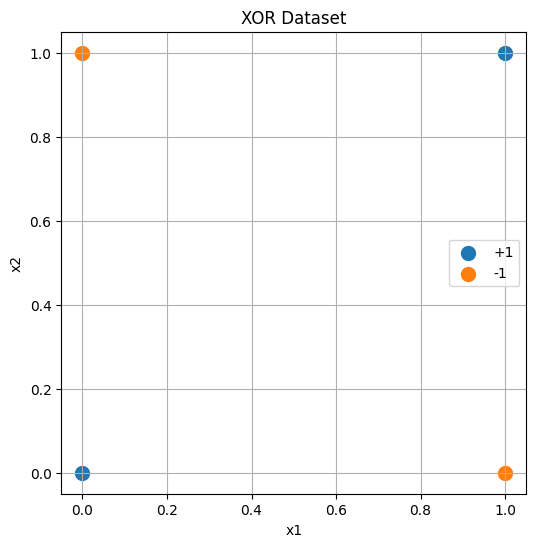

In [297]:
plt.figure(figsize=(6, 6))

positive = y_xor == 1
negative = y_xor == -1

plt.scatter(
    X_xor[positive, 1],
    X_xor[positive, 2],
    label="+1",
    s=100
)

plt.scatter(
    X_xor[negative, 1],
    X_xor[negative, 2],
    label="-1",
    s=100
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR Dataset")
plt.legend()
plt.grid(True)

plt.show()

In [298]:
xor_animation = animate_xor_training(
    X_xor,
    y_xor,
    xor_error_history,
    interval=500
)

display(HTML(xor_animation.to_jshtml()))